In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [ ]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [1]:
import sys, xgboost as xgb
print("Python:", sys.executable)
print("xgboost:", xgb.__version__)


Python: c:\Users\Admin\anaconda3\envs\ml-dl-nlp\python.exe
xgboost: 3.0.4


In [8]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'   # Windows 기본 한글 폰트
plt.rcParams['axes.unicode_minus'] = False      # 마이너스 기호 깨짐 방지


## 데이터 전처리

In [2]:
# 행의 범주 수정
import pandas as pd
from pathlib import Path

# ===== 경로 설정 =====
input_path  = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\WA_Fn-UseC_-HR-Employee-Attrition.csv"
output_path = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\WA_Fn-UseC_-HR-Employee-Attrition_변환.csv"

# ===== 데이터 불러오기 =====
df = pd.read_csv(input_path)

# ===== 매핑 정의 =====
travel_map = {
    'Travel_Rarely': '1~29회',
    'Travel_Frequently': '30회 이상',
    'Non-Travel': '0회'
}

major_map = {
    'Life Sciences': '사회과학계열',
    'Other': '기타',
    'Medical': '자연과학계열',
    'Marketing': '상경계열',
    'Technical Degree': '공학계열',
    'Human Resources': '인문학'
}

jobrole_map = {
    'Sales Executive': '영업직',
    'Research Scientist': '연구직',
    'Laboratory Technician': '엔지니어',
    'Manufacturing Director': '제조 책임자',
    'Healthcare Representative': '연구직 관리자',
    'Manager': '인사관리자',
    'Sales Representative': '영업 담당자',
    'Research Director': '연구 관리자',
    'Human Resources': '인사사원'
}

dept_map = {
    'Sales': '영업',
    'Research & Development': 'R&D',
    'Human Resources': '사무직'
}

# 숫자/문자 모두 대비
eval_map = {3: '보통', 4: '좋다', '3': '보통', '4': '좋다'}

# ===== 유틸: 후보 열 중 존재하는 첫 번째 열 찾기 =====
def pick_col(candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

# ===== 1) 출장 =====
src = pick_col(['출장', 'BusinessTravel'])
if src is not None:
    df['출장'] = df[src].replace(travel_map)

# ===== 2) 전공 =====
src = pick_col(['전공', 'EducationField'])
if src is not None:
    df['전공'] = df[src].replace(major_map)

# ===== 3) 직급 =====
src = pick_col(['직급', 'JobRole'])
if src is not None:
    df['직급'] = df[src].replace(jobrole_map)

# ===== 4) 부서 =====
src = pick_col(['부서', 'Department'])
if src is not None:
    df['부서'] = df[src].replace(dept_map)

# ===== 5) 업무평가 =====
# 보통 원본이 숫자 3/4 이지만, 문자열일 수도 있어 둘 다 매핑
src = pick_col(['업무평가', 'PerformanceRating'])
if src is not None:
    df['업무평가'] = df[src].replace(eval_map)

# ===== 저장 =====
Path(output_path).parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_path, index=False, encoding='utf-8-sig')

# ===== 확인용 출력 (존재하는 컬럼만 보여주기) =====
preview_cols = [c for c in ['출장', '전공', '직급', '부서', '업무평가'] if c in df.columns]
print("변환된 CSV 저장 완료:", output_path)
if preview_cols:
    print("\n[변환 결과 미리보기]")
    print(df[preview_cols].head().to_string(index=False))

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Admin\\OneDrive\\바탕 화면\\2차 플젝\\WA_Fn-UseC_-HR-Employee-Attrition.csv'

In [8]:

import pandas as pd
import numpy as np

# 원본 CSV 경로
csv_path = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\인사평가.csv"

# 변환된 CSV 저장 경로
save_path = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\인사평가_환율변환.csv"

# 데이터 불러오기
try:
    df = pd.read_csv(csv_path)
except UnicodeDecodeError:
    df = pd.read_csv(csv_path, encoding="cp949")

# 환율
USD_TO_KRW = 1350

# 급여 관련 컬럼 자동 탐색 (대소문자 무시)
# 일당, 시급 키워드까지 포함
keywords = ["월급", "연봉", "income", "salary", "급여", "일당", "시급"]
salary_cols = [col for col in df.columns 
               if any(k in col.lower() for k in keywords)]

# 원화 변환 적용
for c in salary_cols:
    if np.issubdtype(df[c].dtype, np.number):
        df[c] = df[c] * USD_TO_KRW
        print(f"[단위 변환] {c}: USD → 원화(KRW) 변환 완료")

# 변환된 데이터 저장
df.to_csv(save_path, index=False, encoding="utf-8-sig")
print(f" 변환 완료! 저장 위치: {save_path}")


[단위 변환] 월급: USD → 원화(KRW) 변환 완료
 변환 완료! 저장 위치: C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\인사평가_환율변환.csv


In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\인사평가_환율변환.csv")

# 열 이름 보기
print(df.columns)


Index(['나이', '회사와의마찰', '출장', '부서', '거리', '학력', '전공', '사번', '만족도', '성별',
       '참여프로젝트', '근속연차', '직급', '직업만족도', '결혼여부', '월급', '이직회수', '성인여부', '야근',
       '업무평가', '주변평가', '근무기준시간', '스톡옵션레벨', '경력', '전년도교육출장횟수', '워라밸',
       '현회사근속년수'],
      dtype='object')


## 피쳐값 특성 파악

In [5]:
%pip install -q openpyxl

Note: you may need to restart the kernel to use updated packages.


### 1) Feature Importance

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ===== 0) 경로/설정 =====
INPUT_CSV = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\인사평가_환율변환.csv"   # 파일 경로 확인
OUTDIR    = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\피처임포턴스_결과_Label"   # 폴더
TARGET_COL = "업무평가"
DROP_COLS  = ["사번", "학력", "거리", "성인여부"]

os.makedirs(OUTDIR, exist_ok=True)
OUT_CSV = os.path.join(OUTDIR, "feature_importance_label_table.csv")
OUT_PNG = os.path.join(OUTDIR, "feature_importance_label_top30.png")

# ===== 1) 데이터 로드(인코딩 자동 시도 + 컬럼 공백 제거) =====
def read_csv_smart(path):
    for enc in ("utf-8", "cp949"):
        try:
            df = pd.read_csv(path, encoding=enc)
            df.columns = df.columns.str.strip()
            return df
        except Exception:
            continue
    raise FileNotFoundError(f"CSV를 읽을 수 없습니다: {path}")

df = read_csv_smart(INPUT_CSV)
if TARGET_COL not in df.columns:
    raise ValueError(f"'{TARGET_COL}' 컬럼이 없습니다. 실제 컬럼명을 확인하세요. 현재 컬럼들: {df.columns.tolist()}")

# ===== 2) 타깃 매핑(이진) =====
def map_binary(series: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(series):
        uniq = sorted(series.dropna().unique().tolist())
        if len(uniq) != 2:
            raise ValueError(f"이진분류를 위해 '{TARGET_COL}'의 유일값이 2개여야 합니다. 현재: {uniq}")
        lo, hi = uniq[0], uniq[1]
        return series.replace({lo: 0, hi: 1}).astype(int)
    # 문자열 케이스
    s = series.astype(str).str.strip()
    mapping = {"보통":0,"보통(0)":0,"0":0,"좋다":1,"좋음":1,"1":1}
    mapped = s.map(mapping)
    if mapped.isna().any():
        top2 = s.value_counts().index.tolist()[:2]
        if len(top2) == 2:
            auto_map = {top2[0]:0, top2[1]:1}
            mapped = s.map(auto_map)
    if mapped.isna().any():
        raise ValueError(f"'{TARGET_COL}'을(를) 0/1로 매핑 실패. 값 분포 확인 필요.")
    return mapped.astype(int)

y = map_binary(df[TARGET_COL])

# ===== 3) 피처 구성 (제외열 드롭) =====
use_cols = [c for c in df.columns if c not in (DROP_COLS + [TARGET_COL])]
X = df[use_cols].copy()

# dtype 정리 (문자/숫자 자동 판별)
cat_cols = [c for c in X.columns if X[c].dtype == "object"]
num_cols = [c for c in X.columns if c not in cat_cols]

# 결측/이상치 처리: 범주형 결측은 '미상', 수치형 결측은 중앙값
cat_transform = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="constant", fill_value="미상")),
    ("encode", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])
num_transform = Pipeline(steps=[
    ("to_numeric", SimpleImputer(strategy="median"))
])

pre = ColumnTransformer(
    transformers=[
        ("cat", cat_transform, cat_cols),
        ("num", num_transform, num_cols),
    ],
    remainder="drop"
)

# ===== 4) 모델 (XGBoost 우선, 불가 시 RF 폴백) =====
use_xgb = True
try:
    from xgboost import XGBClassifier
    clf = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        tree_method="hist",
    )
except Exception:
    use_xgb = False
    from sklearn.ensemble import RandomForestClassifier
    clf = RandomForestClassifier(n_estimators=600, random_state=42, n_jobs=-1)

pipe = Pipeline([("pre", pre), ("clf", clf)])

# ===== 5) 전체 데이터로 학습 (임포턴스만 목적) =====
pipe.fit(X, y)

# ===== 6) 피처 이름 (라벨 인코딩이므로 원 컬럼 수와 동일) =====
feature_names = cat_cols + num_cols  # ColumnTransformer 순서: cat -> num

# ===== 7) 중요도 추출 (XGB: gain, RF: impurity) =====
import pandas as pd
if use_xgb:
    booster = pipe.named_steps["clf"].get_booster()
    gain_dict = booster.get_score(importance_type="gain")  # f0,f1,... 키
    mapped = []
    for i, fname in enumerate(feature_names):
        gain = gain_dict.get(f"f{i}", 0.0)
        mapped.append((fname, gain))
    fi_df = pd.DataFrame(mapped, columns=["feature", "importance_gain"]).sort_values("importance_gain", ascending=False)
else:
    importances = pipe.named_steps["clf"].feature_importances_
    fi_df = (pd.DataFrame({"feature": feature_names, "importance_gain": importances})
             .sort_values("importance_gain", ascending=False))

# ===== 8) 저장 & 시각화 =====
fi_df.to_csv(OUT_CSV, index=False)

topk = fi_df.head(30).iloc[::-1]
plt.figure(figsize=(10, 12))
plt.barh(topk["feature"], topk["importance_gain"])  # 색 지정 X(기본)
plt.title("[Label Encoded] Feature Importance (Top 30)" + (" - gain" if use_xgb else ""))
plt.tight_layout()
plt.savefig(OUT_PNG)
plt.close()

print("[완료] 피처 임포턴스 저장")
print(f"- 표 CSV : {OUT_CSV}")
print(f"- 그래프 : {OUT_PNG}")
print("\n상위 20개 미리보기:")
print(fi_df.head(20))


C:\Users\Admin\AppData\Local\Temp\ipykernel_19704\1215286820.py:135: UserWarning: Glyph 44540 (\N{HANGUL SYLLABLE GEUN}) missing from current font.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19704\1215286820.py:135: UserWarning: Glyph 47924 (\N{HANGUL SYLLABLE MU}) missing from current font.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19704\1215286820.py:135: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from current font.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19704\1215286820.py:135: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from current font.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19704\1215286820.py:135: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from current font.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_19704\1215286820.py:135: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from current font.
  plt.tight_lay

[완료] 피처 임포턴스 저장
- 표 CSV : C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\피처임포턴스_결과_Label\feature_importance_label_table.csv
- 그래프 : C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\피처임포턴스_결과_Label\feature_importance_label_top30.png

상위 20개 미리보기:
      feature  importance_gain
1          출장         1.102554
20        워라밸         1.079570
14       이직회수         1.042326
6        결혼여부         1.035020
5          직급         1.024845
10     참여프로젝트         1.019256
13         월급         1.014144
3          전공         1.002095
18         경력         0.994035
0      회사와의마찰         0.990582
19  전년도교육출장횟수         0.987662
21    현회사근속년수         0.984331
9         만족도         0.980700
8          나이         0.958664
15       주변평가         0.951545
2          부서         0.924213
7          야근         0.916706
12      직업만족도         0.900914
11       근속연차         0.850101
17     스톡옵션레벨         0.844306


### 2) Pearson Correlation

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ===== 0) 경로/설정 =====
INPUT_CSV = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\인사평가_환율변환.csv"
OUTDIR    = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\피어슨상관_결과"
TARGET_COL = "업무평가"
DROP_COLS  = ["사번", "학력", "거리", "성인여부"]

os.makedirs(OUTDIR, exist_ok=True)
OUT_CSV_PEAR  = os.path.join(OUTDIR, "feature_correlation_pearson.csv")
OUT_PNG_PEAR  = os.path.join(OUTDIR, "feature_correlation_top30_pearson.png")

# ===== 1) 데이터 로드 =====
def read_csv_smart(path):
    for enc in ("utf-8", "cp949"):
        try:
            df = pd.read_csv(path, encoding=enc)
            df.columns = df.columns.str.strip()
            return df
        except Exception:
            continue
    raise FileNotFoundError(f"CSV를 읽을 수 없습니다: {path}")

df = read_csv_smart(INPUT_CSV)
if TARGET_COL not in df.columns:
    raise ValueError(f"'{TARGET_COL}' 컬럼이 없습니다. 현재 컬럼들: {df.columns.tolist()}")

# ===== 2) 타깃 매핑(이진) =====
def map_binary(series: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(series):
        uniq = sorted(series.dropna().unique().tolist())
        if len(uniq) != 2:
            raise ValueError(f"이진분류용 타깃 유일값 2개 필요. 현재: {uniq}")
        lo, hi = uniq[0], uniq[1]
        return series.replace({lo:0, hi:1}).astype(int)
    s = series.astype(str).str.strip()
    mapping = {"보통":0,"보통(0)":0,"0":0,"좋다":1,"좋음":1,"1":1}
    m = s.map(mapping)
    if m.isna().any():
        top2 = s.value_counts().index.tolist()[:2]
        if len(top2) == 2:
            m = s.map({top2[0]:0, top2[1]:1})
    if m.isna().any():
        raise ValueError(f"'{TARGET_COL}' 0/1 매핑 실패. 값 분포 확인.")
    return m.astype(int)

y = map_binary(df[TARGET_COL])

# ===== 3) 피처 구성 (제외열 드롭) =====
use_cols = [c for c in df.columns if c not in (DROP_COLS + [TARGET_COL])]
X = df[use_cols].copy()

# ===== 4) 전처리 (라벨 인코딩/결측 처리) =====
cat_cols = [c for c in X.columns if X[c].dtype == "object"]
num_cols = [c for c in X.columns if c not in cat_cols]

cat_transform = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="constant", fill_value="미상")),
    ("encode", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])
num_transform = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median"))
])

pre = ColumnTransformer(
    transformers=[
        ("cat", cat_transform, cat_cols),
        ("num", num_transform, num_cols),
    ],
    remainder="drop"
)

# ===== 5) 전처리 적용 & Pearson 계산 =====
X_t = pre.fit_transform(X)                 # numpy array
feature_names = cat_cols + num_cols        # ColumnTransformer 순서(cat -> num)
X_proc = pd.DataFrame(X_t, columns=feature_names, index=X.index)

df_corr = pd.concat([X_proc, y.rename(TARGET_COL)], axis=1)

pear = df_corr.corr(numeric_only=True)[TARGET_COL].drop(TARGET_COL).to_frame(name="pearson")
pear["abs_pearson"] = pear["pearson"].abs()
pear = pear.sort_values("abs_pearson", ascending=False)

# ===== 6) 저장 =====
pear.to_csv(OUT_CSV_PEAR, encoding="utf-8-sig")

# ===== 7) 시각화(Top-30, 값 라벨 표시) =====
top = pear["pearson"].abs().head(30).iloc[::-1]  # 작은값 아래, 큰값 위
plt.figure(figsize=(12, 9))
bars = plt.barh(top.index, top.values)  # 색상 기본값 사용
plt.title("[Pearson] Feature-Target Correlation (Top 30)")
plt.xlabel("Absolute Pearson Correlation")

# 막대에 수치 라벨 달기
for b in bars:
    w = b.get_width()
    plt.text(w + 0.0005, b.get_y() + b.get_height()/2, f"{w:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(OUT_PNG_PEAR)
plt.close()

print("[완료] Pearson 상관계수 저장")
print(f"- CSV : {OUT_CSV_PEAR}")
print(f"- PNG : {OUT_PNG_PEAR}")
print("\n[상위 15개 미리보기]")
print(pear.head(15))


posx and posy should be finite values
posx and posy should be finite values


[완료] Pearson 상관계수 저장
- CSV : C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\피어슨상관_결과\feature_correlation_pearson.csv
- PNG : C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\피어슨상관_결과\feature_correlation_top30_pearson.png

[상위 15개 미리보기]
            pearson  abs_pearson
부서        -0.032669     0.032669
주변평가      -0.031351     0.031351
만족도       -0.029548     0.029548
참여프로젝트    -0.029071     0.029071
근속연차      -0.021222     0.021222
월급        -0.017120     0.017120
전년도교육출장횟수 -0.015579     0.015579
이직회수      -0.014095     0.014095
성별        -0.013859     0.013859
전공         0.011973     0.011973
직급         0.008582     0.008582
경력         0.006744     0.006744
결혼여부       0.005207     0.005207
야근         0.004369     0.004369
스톡옵션레벨     0.003506     0.003506


### 3) 상관계수 히트맵

C:\Users\Admin\AppData\Local\Temp\ipykernel_20808\3010232447.py:14: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = df.corr(method='pearson')


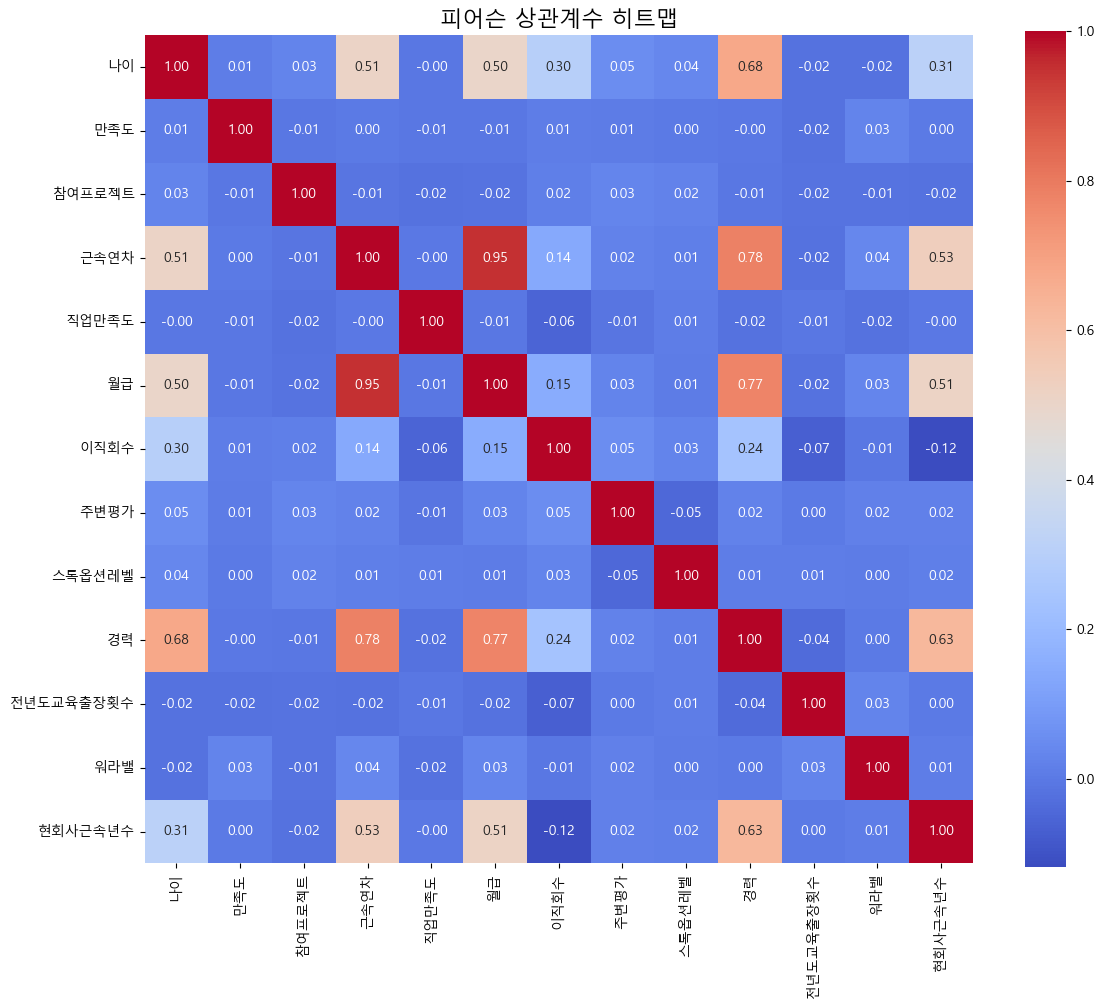

In [13]:
# 상관계수 히트맵
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# CSV 불러오기
df = pd.read_csv(r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\인사평가_환율변환.csv")

# 타겟과 필요 없는 열 제거 (예시)
drop_cols = ['사번', '학력', '거리', '성인여부', '근무기준시간']  # 필요시 수정
df = df.drop(columns=drop_cols, errors='ignore')

# 피어슨 상관계수 계산
corr = df.corr(method='pearson')

# 히트맵 시각화
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,           # 각 칸에 숫자 표시
    fmt=".2f",            # 소수점 2자리
    cmap='coolwarm',      # 색상 맵
    cbar=True,            # 오른쪽 색상바 표시
    square=True           # 정사각형 칸
)
plt.title('피어슨 상관계수 히트맵', fontsize=16)
plt.tight_layout()
plt.show()


## 변수 제외
 - 만족도, 워라벨, 회사와의 마찰, 야근, 스톡옵션레벨 : 주간적,설문 기반
 - 사번, 결혼여부, 직급, 전공, 부서, 성별 : 고유식별자
 - 근무시간기준 : 상수

## 새로운 피쳐 생성
- 1. 비율(Ratio) 변수
이직률 = 이직회수 / 경력
프로젝트참여율 = 참여프로젝트 / 경력
교육출장참여율 = 전년도교육출장횟수 / 경력
현직근속비율 = 현회사근속년수 / 경력
연봉/경력비율 = 월급 / 경력
연봉/프로젝트비율 = 월급 / 참여프로젝트

- 2. 차이(Difference) 변수
경력-근속연차 = 경력 - 근속연차
근속연차차이 = 근속연차 - 현회사근속년수

- 3. 복합지표(Composite) 변수
프로젝트밀도지수 = (참여프로젝트 + 전년도교육출장횟수) / 경력
평판×근속연차 = 주변평가 * 근속연차
연봉×평판점수 = 월급 * 주변평가

- 4. 나이 기반 변수
경력/나이비율 = 경력 / 나이
근속/나이비율 = 근속연차 / 나이
연봉/나이 = 월급 / 나이
입사나이 = 나이 - 경력 (첫 직장 시작 나이 추정)



In [12]:
import pandas as pd
from pathlib import Path
import numpy as np

# ====== 경로 설정 ======
INPUT_CSV  = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\인사평가_환율변환.csv"
OUTPUT_CSV = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\인사평가_피쳐생성.csv"

# ====== 안전 나눗셈 ======
def safe_div_series(a: pd.Series, b: pd.Series) -> pd.Series:
    """Series 간 안전 나눗셈(0으로 나누기 -> <NA>)"""
    b_ = pd.to_numeric(b, errors="coerce").copy()
    b_.replace(0, np.nan, inplace=True)
    return pd.to_numeric(a, errors="coerce") / b_

# ====== 로드 ======
df = pd.read_csv(INPUT_CSV)

# ====== [중요] 사용 제외 피처 선제 제거 ======
EXCLUDE_COLS = [
    "직업만족도", "워라밸", "회사와의마찰",       # 주관적/설문
    "사번", "성별",                           # 식별 위험
    "결혼여부", "직급", "전공", "부서",         # 범주/식별성 강함
    "근무기준시간",                            # 고정/의미 약함
    "스톡옵션레벨",                           # 주관/해석 가변
    "성인여부", "학력", "거리", "야근", "만족도"                 # 기타
]
drop_targets = [c for c in EXCLUDE_COLS if c in df.columns]
df = df.drop(columns=drop_targets)

print("[제외된 피처]")
for c in drop_targets:
    print(" -", c)

# ====== 파생변수에 필요한 원천 컬럼 확인 ======
required = [
    "출장", "이직회수", "참여프로젝트", "월급", "경력", "전년도교육출장횟수",
    "현회사근속년수", "나이", "주변평가", "근속연차"
]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"다음 컬럼이 CSV에 없습니다: {missing}")

# ====== (추가) '출장' 고정 인코딩(0/1/2) ======
def normalize_travel(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()

    # 대표 표기 매핑
    if s in ["0회", "0", "0.0", "Non-Travel", "non-travel", "non travel"]:
        return 0
    if s in ["1~29회", "1~29", "Travel_Rarely", "travel_rarely", "rarely"]:
        return 1
    if s in ["30회 이상", "30이상", ">=30", "30+", "Travel_Frequently", "travel_frequently", "frequently"]:
        return 2

    # 숫자 → 구간화 (예: 0, 15, 30)
    try:
        v = float(s)
        if v <= 0:
            return 0
        elif v < 30:
            return 1
        else:
            return 2
    except:
        return np.nan

# ====== 숫자형 캐스팅(출장은 제외!) ======
numeric_required = [c for c in required if c != "출장"]
for c in numeric_required:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# 고정 인코딩 컬럼 생성 (원본 '출장' 보존)
df["출장_등급"] = df["출장"].apply(normalize_travel).astype("Int64")

# ====== 파생변수 15개 ======
# 1) 비율(Ratio)
df["이직률"]             = safe_div_series(df["이직회수"], df["경력"])
df["프로젝트참여율"]       = safe_div_series(df["참여프로젝트"], df["경력"])
df["교육출장참여율"]       = safe_div_series(df["전년도교육출장횟수"], df["경력"])
df["현직근속비율"]         = safe_div_series(df["현회사근속년수"], df["경력"])
df["연봉/경력비율"]        = safe_div_series(df["월급"], df["경력"])
df["연봉/프로젝트비율"]     = safe_div_series(df["월급"], df["참여프로젝트"])

# 2) 차이(Difference)
df["경력-근속연차"]        = df["경력"] - df["근속연차"]
df["근속연차차이"]         = df["근속연차"] - df["현회사근속년수"]

# 3) 복합지표(Composite)
df["프로젝트밀도지수"]      = safe_div_series(df["참여프로젝트"] + df["전년도교육출장횟수"], df["경력"])
df["평판×근속연차"]         = pd.to_numeric(df["주변평가"], errors="coerce") * pd.to_numeric(df["근속연차"], errors="coerce")
df["연봉×평판점수"]         = pd.to_numeric(df["월급"], errors="coerce") * pd.to_numeric(df["주변평가"], errors="coerce")

# 4) 나이 기반
df["경력/나이비율"]        = safe_div_series(df["경력"], df["나이"])
df["근속/나이비율"]        = safe_div_series(df["근속연차"], df["나이"])
df["연봉/나이"]            = safe_div_series(df["월급"], df["나이"])
df["입사나이"]             = pd.to_numeric(df["나이"], errors="coerce") - pd.to_numeric(df["경력"], errors="coerce")

# ====== 값 정리 ======
df.replace([float("inf"), float("-inf")], np.nan, inplace=True)
# df = df.fillna(0)   # (모델 입력시 필요하면 주석 해제)

# ====== 저장 ======
Path(OUTPUT_CSV).parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")

print("\n[파생변수 생성 완료]")
print(f"저장 경로: {OUTPUT_CSV}")
print("\n[생성된 파생 컬럼 15개 + 출장_등급]")
new_cols = [
    "이직률","프로젝트참여율","교육출장참여율","현직근속비율","연봉/경력비율","연봉/프로젝트비율",
    "경력-근속연차","근속연차차이",
    "프로젝트밀도지수","평판×근속연차","연봉×평판점수",
    "경력/나이비율","근속/나이비율","연봉/나이","입사나이",
    "출장_등급"
]
print(new_cols)

# 디버그: 출장 범주 분포 확인
if "출장_등급" in df.columns:
    print("\n[출장_등급 분포]")
    print(df["출장_등급"].value_counts(dropna=False).sort_index())


[제외된 피처]
 - 직업만족도
 - 워라밸
 - 회사와의마찰
 - 사번
 - 성별
 - 결혼여부
 - 직급
 - 전공
 - 부서
 - 근무기준시간
 - 스톡옵션레벨
 - 성인여부
 - 학력
 - 거리
 - 야근
 - 만족도

[파생변수 생성 완료]
저장 경로: C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\인사평가_피쳐생성.csv

[생성된 파생 컬럼 15개 + 출장_등급]
['이직률', '프로젝트참여율', '교육출장참여율', '현직근속비율', '연봉/경력비율', '연봉/프로젝트비율', '경력-근속연차', '근속연차차이', '프로젝트밀도지수', '평판×근속연차', '연봉×평판점수', '경력/나이비율', '근속/나이비율', '연봉/나이', '입사나이', '출장_등급']

[출장_등급 분포]
0        150
1       1043
2        277
<NA>       0
Name: 출장_등급, dtype: Int64


## 새 피쳐의 feature_importance, cumsum 확인

In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# ====== 경로 설정 ======
INPUT_CSV = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\인사평가_피쳐생성.csv"
OUTDIR    = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\newfeature_feature_importance"
Path(OUTDIR).mkdir(parents=True, exist_ok=True)

# ====== 데이터 로드 ======
df = pd.read_csv(INPUT_CSV)

# ====== 타깃 선택(업무평가2 우선, 없으면 업무평가) ======
if "업무평가2" in df.columns:
    target_col = "업무평가2"
elif "업무평가" in df.columns:
    target_col = "업무평가"
else:
    raise ValueError("타깃 컬럼('업무평가2' 또는 '업무평가')을 찾을 수 없습니다.")

# ====== 원본 '출장'은 제거, '출장_등급'만 사용 ======
if "출장" in df.columns:
    df = df.drop(columns=["출장"])
if "출장_등급" not in df.columns:
    print("[경고] '출장_등급' 컬럼이 없습니다. 이전 단계(피처 생성)에서 생성되었는지 확인하세요.")

# ====== 숫자형 피처 자동 선택 (타깃 제외) ======
df_numeric = df.copy()
for c in df_numeric.columns:
    if c == target_col:
        continue
    df_numeric[c] = pd.to_numeric(df_numeric[c], errors="coerce")

# 무한대 처리 → NaN, 타깃 결측 제거
df_numeric.replace([np.inf, -np.inf], np.nan, inplace=True)
df_numeric = df_numeric.dropna(subset=[target_col])

# X, y 분리
y = df_numeric[target_col]
X = df_numeric.drop(columns=[target_col])

# 전부 NaN인 열 제거
all_nan_cols = X.columns[X.isna().all()].tolist()
if all_nan_cols:
    print("[안내] 전부 NaN이라 제거된 열:", all_nan_cols)
    X = X.drop(columns=all_nan_cols)

# 결측치 간단 대체(정확도 중심: 0 대체)
X = X.fillna(0)

# ====== 데이터 분할 ======
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y if y.nunique() > 1 else None
)

# ====== 모델 학습 (RandomForest - 정확도 우선) ======
clf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
clf.fit(X_train, y_train)

# 성능 확인
pred = clf.predict(X_test)
acc = accuracy_score(y_test, pred)
print(f"[Test Accuracy] {acc:.4f}")

# ====== 피처 중요도 산출 ======
importances = clf.feature_importances_
fi = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values("importance", ascending=False).reset_index(drop=True)

# 누적 기여도
fi["cum_importance"] = fi["importance"].cumsum()

# 저장(CSV)
fi_csv = os.path.join(OUTDIR, "feature_importance_rf.csv")
fi.to_csv(fi_csv, index=False, encoding="utf-8-sig")
print(f"[저장] {fi_csv}")

# ====== 시각화: 상위 K개 바차트 ======
TOP_K = min(20, len(fi))
fi_top = fi.head(TOP_K).copy()

plt.figure(figsize=(10, 6))
plt.barh(fi_top["feature"][::-1], fi_top["importance"][::-1])
plt.xlabel("Importance")
plt.title(f"RandomForest Feature Importance (Top {TOP_K})\nAcc={acc:.3f}")
plt.tight_layout()
bar_png = os.path.join(OUTDIR, "feature_importance_bar.png")
plt.savefig(bar_png, dpi=150)
plt.close()
print(f"[저장] {bar_png}")

# ====== 시각화 1: 누적 기여도(X축=인덱스) ======
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, len(fi)+1), fi["cum_importance"], marker="o")
plt.axhline(0.8, linestyle="--")
plt.xlabel("Number of Features (sorted)")
plt.ylabel("Cumulative Importance")
plt.title("Cumulative Feature Importance (Index Axis)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
cumsum_index_png = os.path.join(OUTDIR, "feature_importance_cumsum_index.png")
plt.savefig(cumsum_index_png, dpi=150)
plt.close()
print(f"[저장] {cumsum_index_png}")

# ====== 시각화 2: 누적 기여도(X축=피처명) ======
plt.figure(figsize=(12, 5))
plt.plot(fi["feature"], fi["cum_importance"], marker="o")
plt.axhline(0.8, linestyle="--")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Feature")
plt.ylabel("Cumulative Importance")
plt.title("Cumulative Feature Importance (Feature Axis)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
cumsum_feature_png = os.path.join(OUTDIR, "feature_importance_cumsum_feature.png")
plt.savefig(cumsum_feature_png, dpi=150)
plt.close()
print(f"[저장] {cumsum_feature_png}")

# ====== 누적 80% 도달 지점 출력 ======
idx_80 = (fi["cum_importance"] >= 0.8).idxmax() + 1  # 1-index
print(f"[안내] 누적 80%에 도달하는 최소 피처 개수: {idx_80}")
print("상위 피처(예시):", fi.head(min(10, len(fi)))["feature"].tolist())


[Test Accuracy] 0.8469
[저장] C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\newfeature_feature_importance\feature_importance_rf.csv
[저장] C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\newfeature_feature_importance\feature_importance_bar.png
[저장] C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\newfeature_feature_importance\feature_importance_cumsum_index.png
[저장] C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\newfeature_feature_importance\feature_importance_cumsum_feature.png
[안내] 누적 80%에 도달하는 최소 피처 개수: 16
상위 피처(예시): ['연봉/프로젝트비율', '연봉/나이', '연봉/경력비율', '월급', '연봉×평판점수', '경력/나이비율', '근속/나이비율', '나이', '프로젝트밀도지수', '교육출장참여율']


In [17]:
import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

import xgboost as xgb

# -----------------------------
# 0) 경로
# -----------------------------
CANDIDATES = [r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\인사평가_피쳐생성.csv"]
INPATH = next((p for p in CANDIDATES if os.path.exists(p)), None)
assert INPATH is not None, f"입력 CSV를 찾을 수 없습니다. 확인: {CANDIDATES}"

OUTDIR = r"C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\학습결과"
os.makedirs(OUTDIR, exist_ok=True)

# -----------------------------
# 1) 데이터 로드 & 타깃
# -----------------------------
df = pd.read_csv(INPATH)

target_col = "업무평가2" if "업무평가2" in df.columns else "업무평가"
assert target_col in df.columns, f"타깃 컬럼 '{target_col}' 없음."

y_raw = df[target_col]
y = (y_raw.replace({"보통":0,"좋다":1,"좋음":1}) if y_raw.dtype=="O" else y_raw).astype(int)

# -----------------------------
# 2) X 구성 (간단 전처리)
# -----------------------------
drop_cols = {target_col, "사번", "학력", "성인여부"}  # 필요시 추가
use_cols = [c for c in df.columns if c not in drop_cols]

num_cols = [c for c in use_cols if pd.api.types.is_numeric_dtype(df[c])]
cat_cols = []
if "출장" in use_cols and not pd.api.types.is_numeric_dtype(df["출장"]):
    cat_cols.append("출장")

X_raw = df[sorted(set(num_cols + cat_cols))].copy()

# -----------------------------
# 3) 데이터 분할 (index 추적)
# -----------------------------
idx = X_raw.index.to_numpy()
idx_tr, idx_te = train_test_split(idx, test_size=0.2, random_state=42, stratify=y)
idx_tr, idx_val = train_test_split(idx_tr, test_size=0.2, random_state=42, stratify=y.iloc[idx_tr])

X_tr_raw, X_val_raw, X_te_raw = X_raw.loc[idx_tr], X_raw.loc[idx_val], X_raw.loc[idx_te]
y_tr, y_val, y_te = y.iloc[idx_tr], y.iloc[idx_val], y.iloc[idx_te]

# -----------------------------
# 4) 전처리 파이프라인 (train에만 fit)
# -----------------------------
transformers = []
if num_cols:
    transformers.append(("num", "passthrough", num_cols))
if cat_cols:
    oe = OrdinalEncoder(
        categories=[["0회","1~29회","30회 이상"]],
        handle_unknown="use_encoded_value", unknown_value=-1
    )
    transformers.append(("cat_trip", oe, cat_cols))

ct = ColumnTransformer(transformers=transformers, remainder="drop", verbose_feature_names_out=False)
X_tr = ct.fit_transform(X_tr_raw)
X_val = ct.transform(X_val_raw)
X_te = ct.transform(X_te_raw)

# -----------------------------
# 5) 클래스 불균형 보정
# -----------------------------
pos = int((y_tr == 1).sum())
neg = int((y_tr == 0).sum())
spw = float(neg) / float(pos) if pos > 0 else 1.0

# -----------------------------
# 6) XGBoost 학습 (xgb.train + early_stopping_rounds)
# -----------------------------
dtrain = xgb.DMatrix(X_tr, label=y_tr)
dval   = xgb.DMatrix(X_val, label=y_val)
dtest  = xgb.DMatrix(X_te,  label=y_te)

params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "eta": 0.05,               # learning_rate
    "max_depth": 5,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "lambda": 1.0,             # reg_lambda
    "min_child_weight": 1.0,
    "scale_pos_weight": spw,
    "seed": 42
}

# tree_method='hist'가 구버전에서 안 될 수 있어 try
try:
    params_with_hist = {**params, "tree_method": "hist"}
    watchlist = [(dtrain, "train"), (dval, "eval")]
    bst = xgb.train(
        params=params_with_hist,
        dtrain=dtrain,
        num_boost_round=1000,
        evals=watchlist,
        early_stopping_rounds=50,
        verbose_eval=False
    )
except xgb.core.XGBoostError:
    watchlist = [(dtrain, "train"), (dval, "eval")]
    bst = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=1000,
        evals=watchlist,
        early_stopping_rounds=50,
        verbose_eval=False
    )

# -----------------------------
# 7) 임계값 탐색 (정확도 기준)
# -----------------------------
if hasattr(bst, "best_ntree_limit") and bst.best_ntree_limit:
    val_proba  = bst.predict(dval,  ntree_limit=bst.best_ntree_limit)
    test_proba = bst.predict(dtest, ntree_limit=bst.best_ntree_limit)
else:
    val_proba  = bst.predict(dval)
    test_proba = bst.predict(dtest)

thr_grid = np.round(np.linspace(0.20, 0.80, 61), 2)

def eval_at_threshold(proba, y_true, thr):
    y_pred = (proba >= thr).astype(int)
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1w  = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    return acc, prec, rec, f1w, y_pred

best_thr, best_acc = 0.5, -1.0
for t in thr_grid:
    acc, *_ = eval_at_threshold(val_proba, y_val, t)
    if acc > best_acc:
        best_acc, best_thr = acc, t

acc, prec, rec, f1w, y_pred_te = eval_at_threshold(test_proba, y_te, best_thr)

print(f"[Val] best_threshold={best_thr:.2f} | accuracy={best_acc:.4f}")
print(f"[Test] accuracy={acc:.4f} | precision_w={prec:.4f} | recall_w={rec:.4f} | f1_w={f1w:.4f}")

# -----------------------------
# 8) ROC & 혼동행렬 저장
# -----------------------------
try:
    auc = roc_auc_score(y_te, test_proba)
except:
    auc = np.nan

fpr, tpr, _ = roc_curve(y_te, test_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC Curve (Test)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "roc_curve.png"), dpi=150)
plt.close()

cm = confusion_matrix(y_te, y_pred_te)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
fig, ax = plt.subplots()
disp.plot(ax=ax, values_format="d", colorbar=False)
ax.set_title(f"Confusion Matrix (thr={best_thr:.2f})")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "confusion_matrix.png"), dpi=150)
plt.close()

# -----------------------------
# 9) 예측 결과 저장 (입력 컬럼 + 예측)
# -----------------------------
preds = pd.DataFrame({
    "y_true": y_te.values,
    "p_good": test_proba,
    "y_pred": (test_proba >= best_thr).astype(int)
}, index=idx_te)

preds_out = pd.concat([df.loc[idx_te, X_raw.columns], preds], axis=1)
preds_out.to_csv(os.path.join(OUTDIR, "preds.csv"), index=False, encoding="utf-8-sig")

print(f"\n[저장완료] 폴더: {OUTDIR}")
print(" - roc_curve.png")
print(" - confusion_matrix.png")
print(" - preds.csv")


[Val] best_threshold=0.78 | accuracy=0.8475
[Test] accuracy=0.8435 | precision_w=0.7169 | recall_w=0.8435 | f1_w=0.7751

[저장완료] 폴더: C:\Users\Admin\OneDrive\바탕 화면\2차 플젝\학습결과
 - roc_curve.png
 - confusion_matrix.png
 - preds.csv


In [18]:
from sklearn.metrics import classification_report

# ...
# y_pred_te: 테스트셋 예측 결과 (0/1)
# y_te: 테스트셋 실제값
# best_thr: 최적 임계값

print("\n[Classification Report - Test]")
print(classification_report(
    y_te, 
    y_pred_te, 
    target_names=["보통(0)", "좋다(1)"],  # 클래스명 지정
    digits=4                             # 소수점 자리수
))



[Classification Report - Test]
              precision    recall  f1-score   support

       보통(0)     0.8464    0.9960    0.9151       249
       좋다(1)     0.0000    0.0000    0.0000        45

    accuracy                         0.8435       294
   macro avg     0.4232    0.4980    0.4576       294
weighted avg     0.7169    0.8435    0.7751       294



In [20]:
%pip install imbalanced-learn


  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached scikit_learn-1.7.1-cp310-cp310-win_amd64.whl.metadata (11 kB)
Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl (12.9 MB)
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   -------- ------------------------------- 2.4/11.1 MB 12.2 MB/s eta 0:00:01
   ---------------- ----------------------- 4.7/11.1 MB 11.9 MB/s eta 0:00:01
   ------------------------- -------------- 7.1/11.1 MB 11.8 MB/s eta 0:00:01
   --------------------------------- ------ 9.4/11.1 MB 11.7 MB/s eta 0:00:01
   ---------------------------------------- 11.1/11.1 MB 11.0 MB/s  0:00:01

  Attempting uninstall: numpy

    Found existing installation: numpy 1.23.5

   ---------------------------------------- 0/4 [numpy]
    Uninstalling numpy-1.23.5:
   ---------------------------------------- 0/4 [numpy]
      Successfully uninstalled numpy-1.23.5
   ---------------------------------------- 0/4 [numpy]
   ---------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  You can safely remove it manually.


In [21]:
# -*- coding: utf-8 -*-
"""
세 가지 조합으로 Borderline-SMOTE + XGBoost 이진분류 실행
- 목표: '좋다(1)' precision >= 0.5
- 최종 임계값: precision>=0.5 만족 후보 중 val-accuracy 최대(없으면 precision 최대)
- 출력: 각 조합별 [Test] 성능 및 Classification Report, ROC/CM/preds 저장
"""
import os, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

# resampling
from imblearn.over_sampling import BorderlineSMOTE

# xgboost (구버전 호환 위해 DMatrix + train 사용)
import xgboost as xgb

# =========================
# 경로
# =========================
INPATH = "C:/Users/Admin/OneDrive/바탕 화면/2차 플젝/인사형가_피쳐생성.csv"   # 필요시 변경
OUTDIR = "C:/Users/Admin/OneDrive/바탕 화면/2차 플젝/학습결과"               # 필요시 변경
os.makedirs(OUTDIR, exist_ok=True)

# =========================
# 1) 데이터 로드 & 타깃
# =========================
df = pd.read_csv(INPATH)
target_col = "업무평가2" if "업무평가2" in df.columns else "업무평가"
y_raw = df[target_col]
y = y_raw.replace({"보통":0, "좋다":1, "좋음":1}).astype(int) if y_raw.dtype == "O" else y_raw.astype(int)

# =========================
# 2) X 구성 (간단 전처리)
# =========================
drop_cols = {target_col, "사번", "학력", "성인여부"}
use_cols = [c for c in df.columns if c not in drop_cols]

num_cols = [c for c in use_cols if pd.api.types.is_numeric_dtype(df[c])]
cat_cols = []
if "출장" in use_cols and not pd.api.types.is_numeric_dtype(df["출장"]):
    cat_cols.append("출장")

X_raw = df[sorted(set(num_cols + cat_cols))].copy()

# =========================
# 3) 데이터 분할 (원본 분포 유지)
# =========================
idx_all = X_raw.index.to_numpy()
idx_tr, idx_te = train_test_split(idx_all, test_size=0.2, random_state=42, stratify=y)
idx_tr, idx_val = train_test_split(idx_tr, test_size=0.2, random_state=42, stratify=y.iloc[idx_tr])

X_tr_raw, X_val_raw, X_te_raw = X_raw.loc[idx_tr], X_raw.loc[idx_val], X_raw.loc[idx_te]
y_tr, y_val, y_te = y.iloc[idx_tr], y.iloc[idx_val], y.iloc[idx_te]

# =========================
# 4) 전처리 파이프라인 (train에만 fit)
# =========================
transformers = []
if num_cols:
    transformers.append(("num", "passthrough", num_cols))
if cat_cols:
    oe = OrdinalEncoder(
        categories=[["0회","1~29회","30회 이상"]],
        handle_unknown="use_encoded_value", unknown_value=-1
    )
    transformers.append(("cat_trip", oe, cat_cols))

ct = ColumnTransformer(transformers=transformers, remainder="drop", verbose_feature_names_out=False)
X_tr = ct.fit_transform(X_tr_raw)
X_val = ct.transform(X_val_raw)
X_te  = ct.transform(X_te_raw)

# =========================
# 공용 유틸
# =========================
def choose_threshold_precision_first(val_proba, y_val, thr_grid, min_prec=0.5):
    """precision(pos=1)>=min_prec 만족하는 t 중 val-accuracy 최대(없으면 precision 최대)"""
    def metrics_at_thr(proba, y_true, thr):
        y_pred = (proba >= thr).astype(int)
        acc  = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
        rec  = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
        f1   = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
        return acc, prec, rec, f1, y_pred

    # 후보: precision>=min_prec
    cands = []
    for t in thr_grid:
        acc, prec, rec, f1, _ = metrics_at_thr(val_proba, y_val, t)
        if prec >= min_prec:
            cands.append((t, acc, prec, rec, f1))
    if cands:
        cands.sort(key=lambda x: (x[1], x[2]), reverse=True)  # acc 우선, 동률이면 precision
        return cands[0][0]
    # 없으면 precision 최대 t
    best_t, best_prec = 0.5, -1
    for t in thr_grid:
        _, prec, _, _, _ = metrics_at_thr(val_proba, y_val, t)
        if prec > best_prec:
            best_prec, best_t = prec, t
    return best_t

def train_and_eval(name, sampler, xgb_params, thr_grid):
    """하나의 조합 실행 & 출력 & 저장"""
    print(f"\n===== [{name}] =====")
    # 5) Resampling (train만)
    if sampler is not None:
        X_tr_rs, y_tr_rs = sampler.fit_resample(X_tr, y_tr)
    else:
        X_tr_rs, y_tr_rs = X_tr, y_tr

    print(f"[INFO] Train dist before: 0={int((y_tr==0).sum())}, 1={int((y_tr==1).sum())}")
    print(f"[INFO] Train dist after : 0={int((y_tr_rs==0).sum())}, 1={int((y_tr_rs==1).sum())}")

    # 6) XGBoost 학습
    dtrain = xgb.DMatrix(X_tr_rs, label=y_tr_rs)
    dval   = xgb.DMatrix(X_val,    label=y_val)
    dtest  = xgb.DMatrix(X_te,     label=y_te)

    watchlist = [(dtrain, "train"), (dval, "eval")]
    bst = xgb.train(
        params=xgb_params,
        dtrain=dtrain,
        num_boost_round=1000,
        evals=watchlist,
        early_stopping_rounds=50,
        verbose_eval=False
    )

    # 예측 확률
    if hasattr(bst, "best_ntree_limit") and bst.best_ntree_limit:
        val_proba  = bst.predict(dval,  ntree_limit=bst.best_ntree_limit)
        test_proba = bst.predict(dtest, ntree_limit=bst.best_ntree_limit)
    else:
        val_proba  = bst.predict(dval)
        test_proba = bst.predict(dtest)

    # 7) 임계값 선택 (precision 우선)
    best_thr = choose_threshold_precision_first(val_proba, y_val, thr_grid, min_prec=0.5)

    # Test 성능
    y_pred_te = (test_proba >= best_thr).astype(int)
    acc  = accuracy_score(y_te, y_pred_te)
    prec = precision_score(y_te, y_pred_te, pos_label=1, zero_division=0)
    rec  = recall_score(y_te, y_pred_te, pos_label=1, zero_division=0)
    f1   = f1_score(y_te, y_pred_te, pos_label=1, zero_division=0)

    print(f"[Thr] {best_thr:.2f}")
    print(f"[Test] acc={acc:.4f} | precision(1)={prec:.4f} | recall(1)={rec:.4f} | f1(1)={f1:.4f}")
    print("\n[Classification Report - Test]")
    print(classification_report(y_te, y_pred_te, target_names=["보통(0)", "좋다(1)"], digits=4))

    # 8) 저장물
    # ROC
    try:
        auc = roc_auc_score(y_te, test_proba)
    except:
        auc = np.nan
    fpr, tpr, _ = roc_curve(y_te, test_proba)
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
    plt.plot([0,1],[0,1], linestyle="--")
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, f"roc_{name}.png"), dpi=150)
    plt.close()

    # Confusion Matrix
    cm = confusion_matrix(y_te, y_pred_te)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["보통(0)","좋다(1)"])
    fig, ax = plt.subplots()
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(f"Confusion Matrix - {name} (thr={best_thr:.2f})")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, f"cm_{name}.png"), dpi=150)
    plt.close()

    # preds.csv
    preds = pd.DataFrame({
        "y_true": y_te.values,
        "p_good": test_proba,
        "y_pred": y_pred_te
    }, index=idx_te)
    preds_out = pd.concat([df.loc[idx_te, X_raw.columns], preds], axis=1)
    preds_out.to_csv(os.path.join(OUTDIR, f"preds_{name}.csv"), index=False, encoding="utf-8-sig")

# =========================
# 조합 정의 & 실행
# =========================
# 공통: thr grid(precision 올리려면 높은 쪽까지 탐색)
THR_GRID_A = np.round(np.linspace(0.30, 0.95, 66), 2)
THR_GRID_B = np.round(np.linspace(0.40, 0.95, 56), 2)
THR_GRID_C = np.round(np.linspace(0.50, 0.98, 49), 2)

# (A) BorderlineSMOTE(b1) + spw=3.0 + 기본 트리
sampler_A = BorderlineSMOTE(random_state=42, kind="borderline-1")
params_A = {
    "objective":"binary:logistic","eval_metric":"logloss",
    "eta":0.05,"max_depth":5,"subsample":0.9,"colsample_bytree":0.9,
    "lambda":1.0,"min_child_weight":1.0,"tree_method":"hist","seed":42,
    "scale_pos_weight":3.0
}

# (B) BorderlineSMOTE(b2) + spw=1.0 + 기본 트리
sampler_B = BorderlineSMOTE(random_state=42, kind="borderline-2")
params_B = {
    "objective":"binary:logistic","eval_metric":"logloss",
    "eta":0.05,"max_depth":5,"subsample":0.9,"colsample_bytree":0.9,
    "lambda":1.0,"min_child_weight":1.0,"tree_method":"hist","seed":42,
    "scale_pos_weight":1.0
}

# (C) BorderlineSMOTE(b1) + spw=1.0 + 보수적 트리(precision 강화)
sampler_C = BorderlineSMOTE(random_state=42, kind="borderline-1")
params_C = {
    "objective":"binary:logistic","eval_metric":"logloss",
    "eta":0.03,"max_depth":4,"subsample":0.9,"colsample_bytree":0.9,
    "lambda":1.5,"min_child_weight":2.0,"tree_method":"hist","seed":42,
    "scale_pos_weight":1.0
}

# 실행
train_and_eval("A_b1_spw3", sampler_A, params_A, THR_GRID_A)
train_and_eval("B_b2_spw1", sampler_B, params_B, THR_GRID_B)
train_and_eval("C_b1_spw1_cons", sampler_C, params_C, THR_GRID_C)

print(f"\n[저장 완료] 결과 폴더: {OUTDIR}")
print("- roc_*.png, cm_*.png, preds_*.csv (조합별 저장)")


ImportError: cannot import name 'UnsetMetadataPassedError' from 'sklearn.exceptions' (C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\sklearn\exceptions.py)